In [1]:
from pathlib import Path
import json, pickle, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import torch
sns.set_style(style="whitegrid")


%load_ext autoreload
%autoreload 2

NB   = Path.cwd()
ROOT = NB.parent
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from data_pipeline.config import CLEANED

RUN_DIR = Path(ROOT / "models/gae_run3")
CKPT = RUN_DIR / "best.pt"
CONF = RUN_DIR / "config.json"
RESULTS = RUN_DIR / "results.json"  # created by train_gae when save_outdir set
RUN_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Paths/config
CLEANED = ROOT / 'data' / 'processed' / 'cleaned'
RUN_DIR = ROOT / 'models' / 'gae_run3'
CONF = RUN_DIR / 'config.json'
CKPT = RUN_DIR / 'best.pt'
assert CONF.exists(), f'Missing config: {CONF}'
assert CKPT.exists(), f'Missing checkpoint: {CKPT}'


In [3]:
# --- 1) Load panel exported from 02_simulator ---
import pandas as pd

panel = pd.read_csv(CLEANED / 'hedging_panel_spx.csv', parse_dates=['date']).sort_values('date').reset_index(drop=True)
print('Panel window:', panel['date'].min(), '→', panel['date'].max())
print('Columns:', list(panel.columns))


Panel window: 2005-01-21 00:00:00 → 2023-08-29 00:00:00
Columns: ['date', 'close_spy', 'vix', 'rate_10y', 'hvol_10d', 'hvol_14d', 'hvol_30d', 'hvol_60d', 'hvol_91d', 'hvol_122d', 'hvol_152d', 'hvol_182d', 'hvol_273d', 'hvol_365d', 'hvol_547d', 'hvol_730d', 'hvol_1825d', 'fwd_front', 'high_spy', 'low_spy', 'open_spy', 'rv_21d', 'rv_60d', 'rv_120d', 'iv_atm_30d_spx', 'iv_atm_91d_spx', 'delta_atm_30d_spx', 'iv_atm_60d_spx', 'iv_ts_slope_spx', 'iv_put25_30d_spx', 'iv_call25_30d_spx', 'iv_skew_30d_spx', 'iv_put25_60d_spx', 'iv_call25_60d_spx', 'iv_skew_60d_spx', 'ret_fwd']


In [4]:
from rl_agent.train_ac_gae import PolicyValueNet
from rl_agent.experiment import build_envs, deterministic_rewards
from rl_agent.trainer import evaluate_env

cfg = json.loads(CONF.read_text())
envs = build_envs(
    panel=panel,
    features=cfg.get('state_cols', cfg['features']),
    train_end=cfg['train_end'],
    valid_end=cfg['valid_end'],
    window=cfg['window'],
    txn_cost_bps=cfg['txn_cost_bps'],
    pos_limit=cfg['pos_limit'],
    rebalance_every=int(cfg.get('rebalance_every', 1)),
    slippage_bps=float(cfg.get('slippage_bps', 0.0)),
)
env_tr, env_va, env_te = envs['env_tr'], envs['env_va'], envs['env_te']


In [5]:
from rl_agent.train_ac_gae import PolicyValueNet, make_obs_fixer

n_features = len(cfg.get('state_cols', cfg['features']))
to_fixed = make_obs_fixer(cfg['window'], n_features)

net = PolicyValueNet(input_dim=env_tr.reset().size, hidden=cfg['hidden'])
net.load_state_dict(torch.load(CKPT, map_location='cpu'))
net.obs_fix = to_fixed
net.pos_limit = float(cfg['pos_limit'])


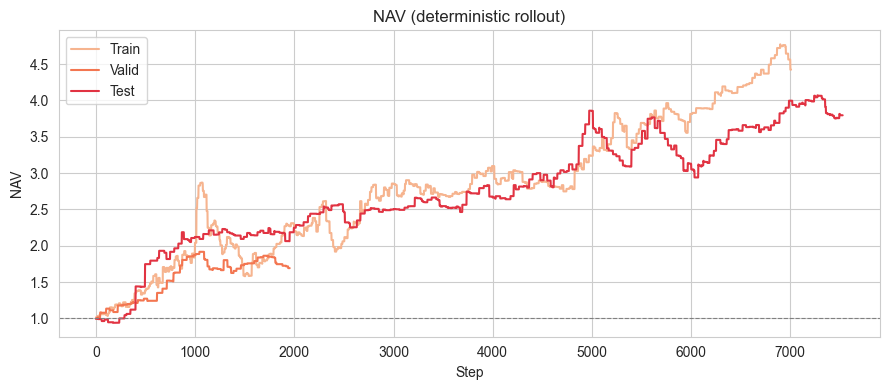

Test turnover (sum |Δpos|): 149.23


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from rl_agent.experiment import deterministic_rewards
from rl_agent.metrics import nav_curve

sns.set_palette("rocket_r")
plt.figure(figsize=(9,4))
r_tr, nav_tr = nav_curve(env_tr, net, "Train")
r_va, nav_va = nav_curve(env_va, net, "Valid")
r_te, nav_te = nav_curve(env_te, net, "Test")
plt.axhline(1.0, color="grey", lw=0.8, ls="--")
plt.title("NAV (deterministic rollout)")
plt.xlabel("Step")
plt.ylabel("NAV")
plt.legend()
plt.tight_layout()
plt.show()

rollout_te = env_te.rollout(lambda obs: net.act(obs, deterministic=True)[0])
positions = rollout_te["positions"]
turnover = np.abs(np.diff(positions)).sum()
print(f"Test turnover (sum |Δpos|): {turnover:.2f}")


In [7]:
from rl_agent.metrics import calc_drawdown

summary = []
curves = {"train": (r_tr, nav_tr), "valid": (r_va, nav_va), "test": (r_te, nav_te)}
for split, (rewards, nav) in curves.items():
    mean = rewards.mean()
    std = rewards.std(ddof=1) if rewards.size > 1 else 0.0
    sharpe = (mean / std * np.sqrt(252)) if std > 0 else 0.0
    turnover = np.abs(np.diff(env_te.rollout(lambda obs: net.act(obs, deterministic=True)[0])['positions'])).sum() if split == 'test' else np.nan
    summary.append({
        'split': split,
        'mean_bps': float(mean),
        'std_bps': float(std),
        'sharpe': float(sharpe),
        'steps': int(rewards.size),
        'max_drawdown': float(calc_drawdown(nav)),
        'turnover': turnover,
    })
summary_df = pd.DataFrame(summary).set_index('split')
display(summary_df)


,mean_bps,std_bps,sharpe,steps,max_drawdown,turnover
split,,,,,,
train,2.430963,79.785546,0.483676,7008,-0.448591,NaN
valid,2.863926,58.949001,0.771233,1954,-0.152073,NaN
test,1.947213,61.531464,0.502362,7529,-0.238162,149.228842


In [8]:
## Save results to RUN_DIR

RUN_DIR.mkdir(parents=True, exist_ok=True)

fig_nav = plt.figure(figsize=(9,3))
  # build NAV plot
fig_nav.savefig(RUN_DIR / "nav_curves.png", dpi=150, bbox_inches="tight")

fig_hist = plt.figure(figsize=(8,3))
  # build histogram
fig_hist.savefig(RUN_DIR / "test_reward_hist.png", dpi=150, bbox_inches="tight")

summary_df.to_csv(RUN_DIR / "evaluation_summary.csv", index=True)

np.save(RUN_DIR / "train_rewards.npy", r_tr)
np.save(RUN_DIR / "valid_rewards.npy", r_va)
np.save(RUN_DIR / "test_rewards.npy",  r_te)


<Figure size 900x300 with 0 Axes>

<Figure size 800x300 with 0 Axes>

## Comparison vs Long SPY

In [9]:
from rl_agent.deploy import load_policy
from rl_agent.experiment import deterministic_rewards
from simulator.baselines import hold_policy, vix_band_policy, vix_vol_target, volatility_targeting
from collections import OrderedDict
import numpy as np

policy_loaded, cfg_loaded, envs_loaded = load_policy(
    run_dir=RUN_DIR,
    panel=panel,
    device="cpu",
)

print("Loaded policy hidden dim:", cfg_loaded["hidden"])
print("Envs keys:", list(envs_loaded.keys()))

# Use envs from deploy helper to keep everything consistent
env_tr, env_va, env_te = envs_loaded["env_tr"], envs_loaded["env_va"], envs_loaded["env_te"]

def _as_actor(fn):
    if hasattr(fn, "act"):
        return fn
    class _Tmp:
        def __init__(self, f):
            self.f = f
        def act(self, obs, deterministic=True):
            return float(self.f(obs)), None, None
    return _Tmp(fn)

# VIX mean/std in train to undo z-scoring for band/vol overlays
train_mask = panel["date"] <= pd.Timestamp(cfg_loaded["train_end"])
vix_mean = float(panel.loc[train_mask, "vix"].mean()) if "vix" in panel else 0.0
vix_std = float(panel.loc[train_mask, "vix"].std(ddof=1)) if "vix" in panel else 1.0
feat_idx = {name: i for i, name in enumerate(cfg_loaded.get("state_cols", cfg_loaded.get("features", [])))}
vix_idx = feat_idx.get("vix", 0)

long_spy = _as_actor(hold_policy(env_te.pos_limit))
gae_actor = _as_actor(policy_loaded)
policies = OrderedDict({
    "gae_policy": gae_actor,
    "long_spy": long_spy,
    "vix_band": _as_actor(vix_band_policy(vix_idx=vix_idx, low=20.0, high=30.0, pos_low=0.0, pos_high=env_te.pos_limit, vix_mean=vix_mean, vix_std=vix_std)),
    "vix_vol_target": _as_actor(vix_vol_target(vix_idx=vix_idx, vix_target=20.0, max_pos=env_te.pos_limit, vix_mean=vix_mean, vix_std=vix_std)),
    "vol_target": _as_actor(volatility_targeting(feature_idx=vix_idx, ann_vol_target=0.15)),
})

# Optionally add ML baseline if saved by 03_rl_training
ml_path = RUN_DIR / "ml_model.pkl"
if ml_path.exists():
    blob = pickle.load(open(ml_path, "rb"))
    class _MLActor:
        def __init__(self, bundle, pos_limit):
            self.model = bundle["model"]
            self.mu = bundle["mu"]
            self.sg = bundle["sg"]
            self.scale = bundle["scale"]
            self.sign = bundle["sign"]
            self.pos_limit = float(pos_limit)
        def act(self, obs, deterministic=True):
            x = obs[-1] if obs.ndim > 1 else obs
            x_norm = (np.asarray(x, float) - self.mu) / self.sg
            pred = float(self.model.predict(x_norm.reshape(1, -1))[0])
            raw = self.sign * pred / self.scale
            import numpy as _np
            hedge = _np.clip(raw * self.pos_limit, -self.pos_limit, self.pos_limit)
            return float(hedge), None, None
    policies["ml_gbr"] = _MLActor(blob, pos_limit=env_te.pos_limit)


Loaded policy hidden dim: 256
Envs keys: ['env_tr', 'env_va', 'env_te', 'input_dim', 'config', 'scaler', 'TRAIN_END', 'VALID_END', 'panel', 'masks']


In [10]:
# --- Extended metrics for GAE policy vs baselines ---
import numpy as np, pandas as pd
from collections import OrderedDict
from rl_agent.metrics import max_drawdown, nav_from_bps, sortino_bps

splits = OrderedDict([('train', env_tr), ('valid', env_va), ('test', env_te)])
rows = []
for pname, pol in policies.items():
    for sname, env in splits.items():
        r = deterministic_rewards(env, pol)
        nav = nav_from_bps(r)
        mean = r.mean()
        std = r.std(ddof=1) if r.size > 1 else 0.0
        sharpe = (mean / std * np.sqrt(252)) if std > 0 else 0.0
        sortino = sortino_bps(r)
        rows.append({
            'policy': pname, 'split': sname, 'mean_bps': float(mean), 'std_bps': float(std), 'sharpe': float(sharpe),
            'sortino': float(sortino), 'max_drawdown': float(max_drawdown(nav)), 'hit_rate': float((r > 0).mean()), 'steps': int(r.size),
        })
metrics_df = pd.DataFrame(rows)
display(metrics_df)


,policy,split,mean_bps,std_bps,sharpe,sortino,max_drawdown,hit_rate,steps
0,gae_policy,train,2.430963,79.785546,0.483676,0.240710,-0.448591,0.030965,7008
1,gae_policy,valid,2.863926,58.949001,0.771233,0.399896,-0.152073,0.020471,1954
2,gae_policy,test,1.947213,61.531464,0.502362,0.302656,-0.238162,0.017001,7529
3,long_spy,train,1.709183,57.401864,0.472675,0.123199,-0.465637,0.032392,7008
4,long_spy,valid,1.062778,40.035652,0.421401,0.079588,-0.136623,0.021494,1954
5,long_spy,test,0.594999,42.273139,0.223435,0.041306,-0.288406,0.017134,7529
6,vix_band,train,0.302123,43.170576,0.111095,0.019009,-0.402979,0.009275,7008
7,vix_band,valid,0.317151,20.153916,0.249808,0.025769,-0.056896,0.003071,1954
8,vix_band,test,0.370390,39.498566,0.148860,0.022912,-0.257434,0.010493,7529
9,vix_vol_target,train,1.419537,68.388384,0.329507,0.120617,-0.584370,0.032392,7008


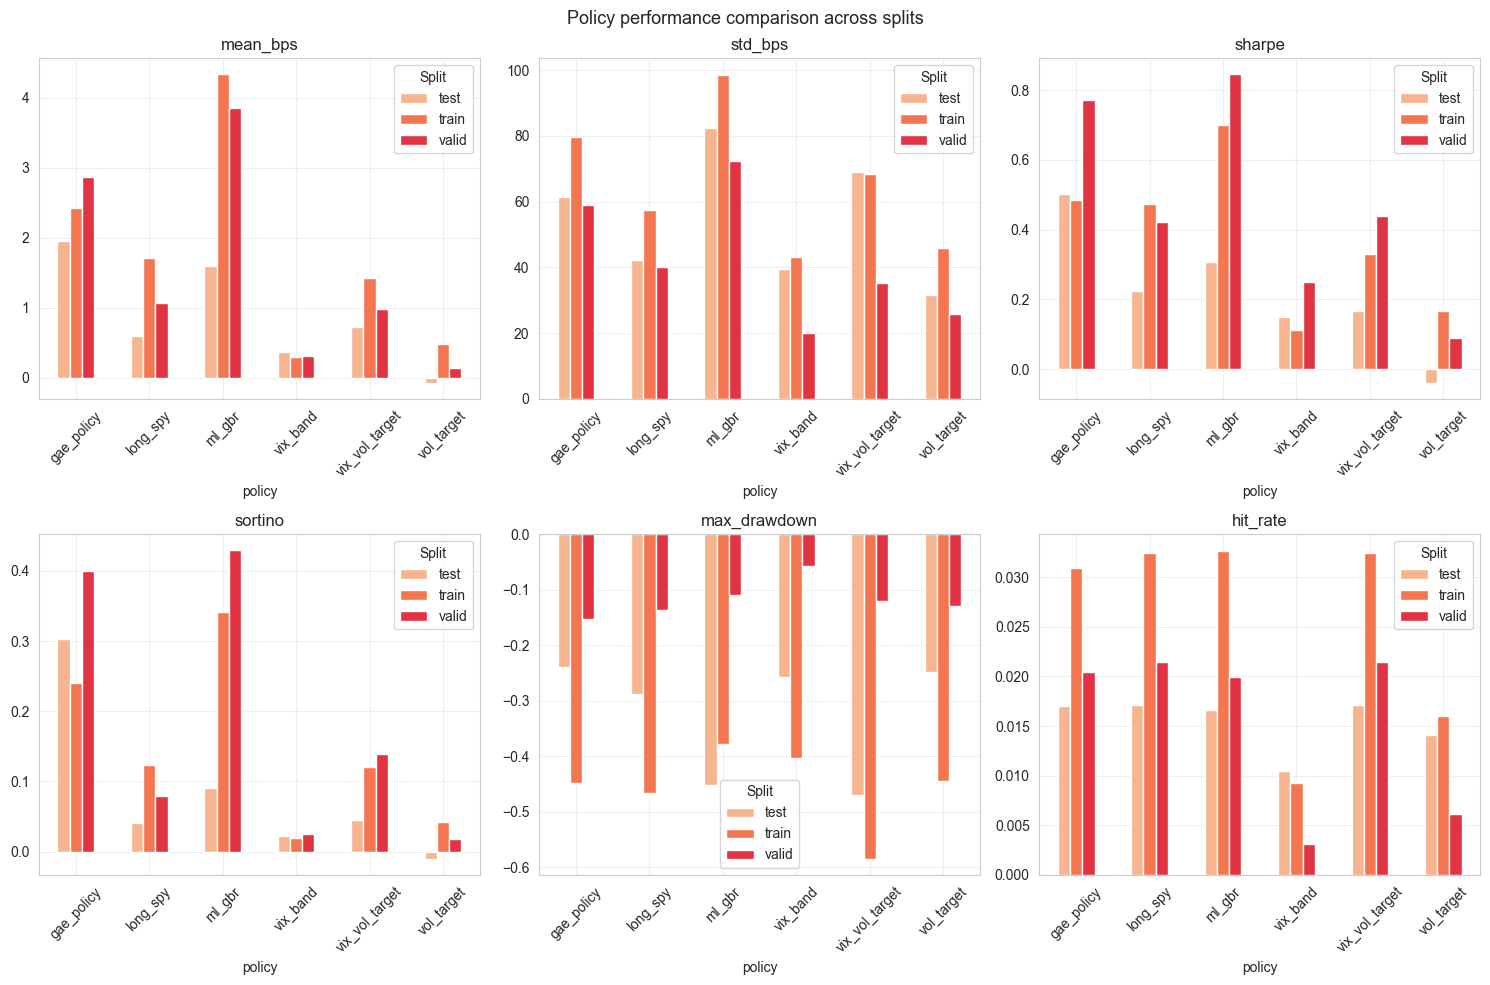

In [11]:
# Create a more readable plot for metrics comparison

sns.set_style(style="whitegrid")
sns.set_palette("rocket_r")
metrics_to_plot = ['mean_bps', 'std_bps', 'sharpe', 'sortino', 'max_drawdown', 'hit_rate']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    data = metrics_df.pivot(index='policy', columns='split', values=metric)
    data.plot(kind='bar', ax=ax, rot=45)
    ax.set_title(metric)
    ax.legend(title='Split')
    ax.grid(True, alpha=0.3)

fig.suptitle("Policy performance comparison across splits", fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'figures' / "policy_performance_comparison.png", dpi=150)
plt.show()

# In Combination with Long SPY

Blend weight (GAE vs SPY): 0.50 / 0.50


,split,mean_bps,std_bps,sharpe,sortino,max_drawdown,hit_rate,cagr,calmar
0,train,2.070073,38.904249,0.844674,0.425087,-0.136156,0.031535,0.051553,0.378629
1,valid,1.963352,34.671081,0.898941,0.480035,-0.086411,0.020471,0.049160,0.568910
2,test,1.271106,34.370250,0.587083,0.359777,-0.096898,0.017399,0.031086,0.320815


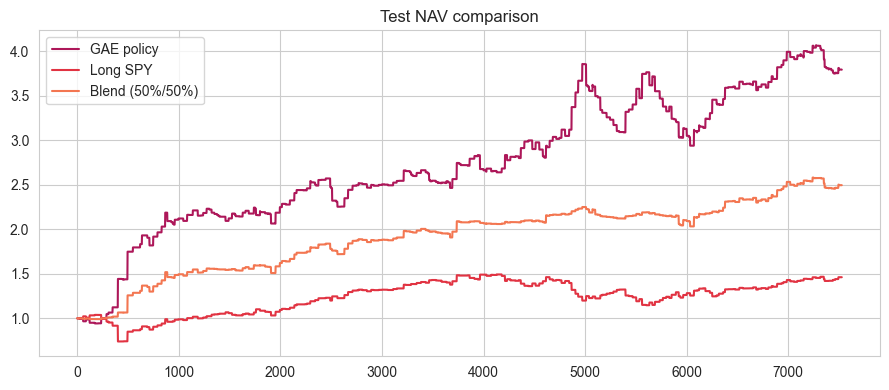

In [12]:
# --- Combined strategy: blend GAE policy with long SPY baseline ---
from rl_agent.metrics import combo_summary, nav_from_bps

blend_weight = 0.5  # portion of capital allocated to GAE; remainder goes to long SPY
print(f"Blend weight (GAE vs SPY): {blend_weight:.2f} / {1-blend_weight:.2f}")

combo_rows = [
    combo_summary(env_tr, net, long_spy, blend_weight, 'train'),
    combo_summary(env_va, net, long_spy, blend_weight, 'valid'),
    combo_summary(env_te, net, long_spy, blend_weight, 'test'),
]
combo_df = pd.DataFrame(combo_rows)
display(combo_df.drop(columns=['nav', 'rewards']))

# Plot NAV comparison on test split
nav_combo = combo_rows[-1]['nav']
nav_gae = nav_from_bps(deterministic_rewards(env_te, net))
nav_spy = nav_from_bps(deterministic_rewards(env_te, long_spy))
plt.figure(figsize=(9, 4))
plt.plot(nav_gae, label='GAE policy', color='C9')
plt.plot(nav_spy, label='Long SPY', color='C2')
plt.plot(nav_combo, label=f"Blend ({blend_weight:.0%}/{(1-blend_weight):.0%})", color='C1')
plt.legend()
plt.title('Test NAV comparison')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'nav_blended_strategy.png')
plt.show()


In [13]:
combo_df.T

,0,1,2
split,train,valid,test
mean_bps,2.070073,1.963352,1.271106
std_bps,38.904249,34.671081,34.37025
sharpe,0.844674,0.898941,0.587083
sortino,0.425087,0.480035,0.359777
max_drawdown,-0.136156,-0.086411,-0.096898
hit_rate,0.031535,0.020471,0.017399
cagr,0.051553,0.04916,0.031086
calmar,0.378629,0.56891,0.320815
nav,"[0.9977797855019569, 0.9977797855019569, 1.016...","[0.9977768195152282, 0.9977768195152282, 0.997...","[0.99777681286335, 0.99777681286335, 0.9977768..."


In [14]:
# --- Helper series for combo diagnostics ---
gae_rewards_bps = deterministic_rewards(env_te, net)
spy_rewards_bps = deterministic_rewards(env_te, long_spy)
combo_rewards_bps = blend_weight * gae_rewards_bps + (1.0 - blend_weight) * spy_rewards_bps

blend_label = f"Blend ({blend_weight:.0%} GAE / {1 - blend_weight:.0%} SPY)"

combo_returns = pd.DataFrame(
    {
        "GAE policy": gae_rewards_bps / 1e4,
        "Long SPY": spy_rewards_bps / 1e4,
        blend_label: combo_rewards_bps / 1e4,
    }
)

combo_navs = pd.DataFrame(
    {
        "GAE policy": nav_from_bps(gae_rewards_bps),
        "Long SPY": nav_from_bps(spy_rewards_bps),
        blend_label: nav_from_bps(combo_rewards_bps),
    }
)

if "date" in env_te.df.columns:
    date_idx = pd.to_datetime(
        env_te.df.loc[env_te.df["ret_fwd"].notna(), "date"]
    ).reset_index(drop=True)
    start = int(getattr(env_te, "window", 0))
    stop = start + len(combo_rewards_bps)
    reward_index = date_idx.iloc[start:stop].reset_index(drop=True)
else:
    reward_index = pd.RangeIndex(len(combo_rewards_bps))

combo_returns.index = reward_index
combo_navs.index = reward_index
combo_returns.index.name = "date"
combo_navs.index.name = "date"

print(f"Prepared return series for {combo_returns.shape[0]} test steps.")


Prepared return series for 7529 test steps.


#### Rolling risk/return
63-day windows show how the blend stabilizes returns relative to the standalone legs.


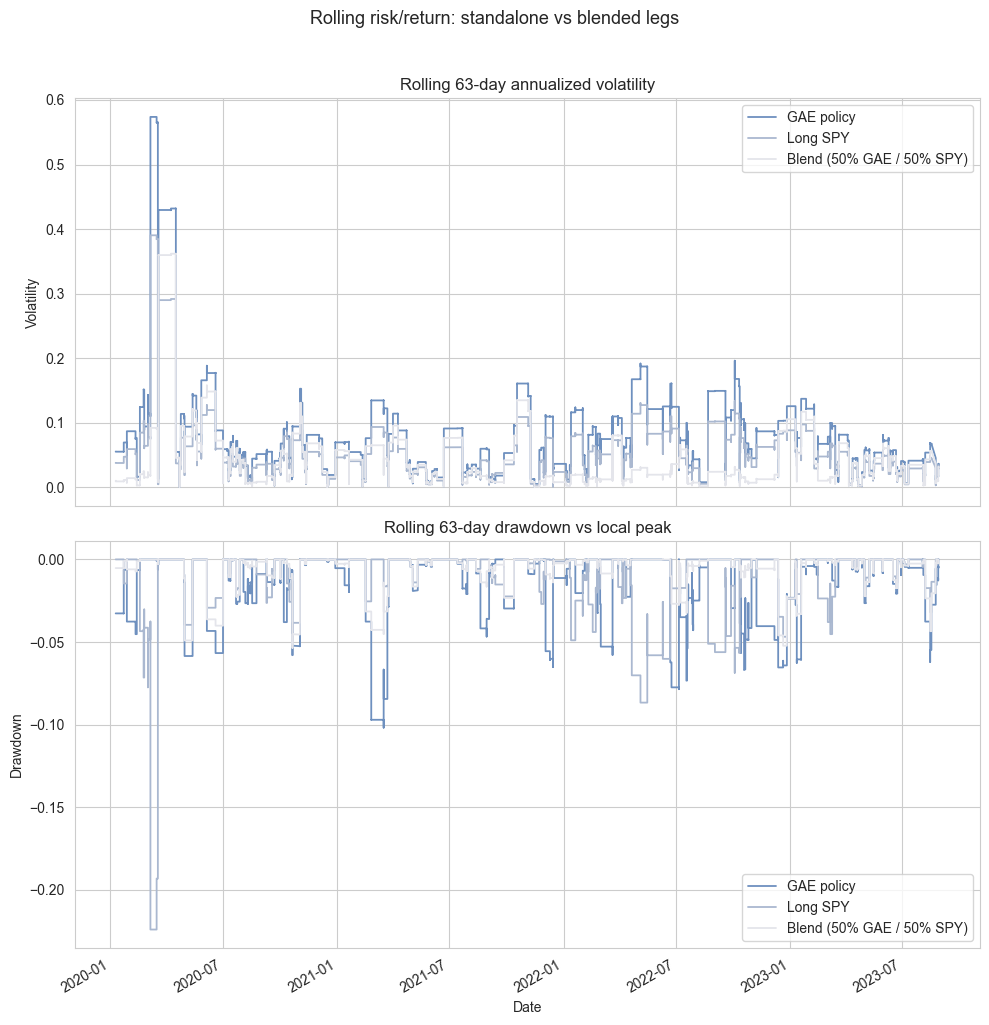

In [15]:
# --- Rolling risk/return diagnostics ---
window = 63  # roughly one quarter
annualizer = np.sqrt(252)
sns.set_palette("vlag")

rolling_mean = combo_returns.rolling(window).mean() * 252
rolling_vol = combo_returns.rolling(window).std(ddof=0) * annualizer
rolling_dd = combo_navs / combo_navs.rolling(window).max() - 1.0

fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
#rolling_mean.plot(ax=axes[0], lw=1.3)
#axes[0].set_title(f"Rolling {window}-day annualized return")
#axes[0].set_ylabel("Return")

rolling_vol.plot(ax=axes[0], lw=1.3)
axes[0].set_title(f"Rolling {window}-day annualized volatility")
axes[0].set_ylabel("Volatility")

rolling_dd.plot(ax=axes[1], lw=1.3)
axes[1].set_title(f"Rolling {window}-day drawdown vs local peak")
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date" if isinstance(combo_returns.index, pd.DatetimeIndex) else "Step")

plt.suptitle("Rolling risk/return: standalone vs blended legs", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "rolling_risk_return.png", dpi=150)
plt.show()


#### Rolling risk differentials
Visualize how the blend's rolling volatility and drawdown deviate from the standalone legs.


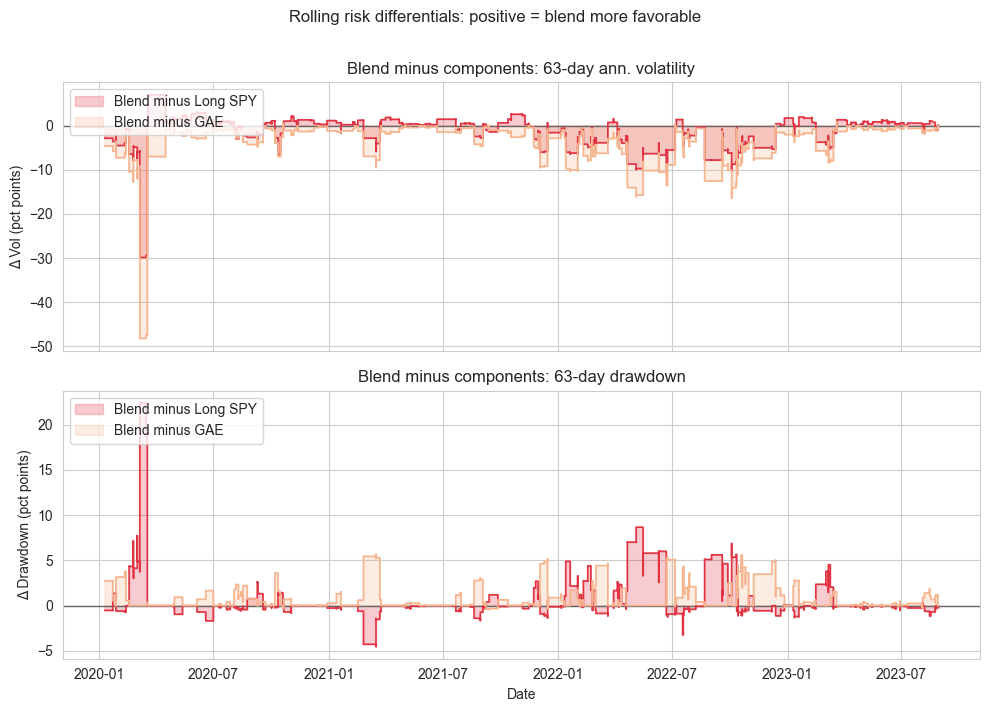

In [16]:
# --- Rolling risk differentials (blend minus components) ---
sns.set_palette("rocket_r")

diff_vol = pd.DataFrame(
    {
        "Blend minus Long SPY": (rolling_vol[blend_label] - rolling_vol["Long SPY"]) * 100,
        "Blend minus GAE": (rolling_vol[blend_label] - rolling_vol["GAE policy"]) * 100,
    },
    index=rolling_vol.index,
)

diff_dd = pd.DataFrame(
    {
        "Blend minus Long SPY": (rolling_dd[blend_label] - rolling_dd["Long SPY"]) * 100,
        "Blend minus GAE": (rolling_dd[blend_label] - rolling_dd["GAE policy"]) * 100,
    },
    index=rolling_dd.index,
)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for ax, data, title, ylabel in [
    (axes[0], diff_vol, f"Blend minus components: {window}-day ann. volatility", "Δ Vol (pct points)"),
    (axes[1], diff_dd, f"Blend minus components: {window}-day drawdown", "Δ Drawdown (pct points)"),
]:
    ax.axhline(0.0, color="0.4", lw=1.0)
    for col, color in zip(data.columns, ["C2", "C0"]):
        ax.fill_between(
            data.index,
            0,
            data[col],
            alpha=0.25,
            color=color,
            step="pre",
            label=col,
        )
        ax.plot(data.index, data[col], color=color, lw=1.2)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(loc="upper left")

axes[1].set_xlabel("Date" if isinstance(data.index, pd.DatetimeIndex) else "Step")
plt.suptitle("Rolling risk differentials: positive = blend more favorable", y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "rolling_risk_differentials.png", dpi=150)
plt.show()


#### Rolling risk heatmaps
Monthly heatmaps emphasize the regimes where each strategy carries more risk.


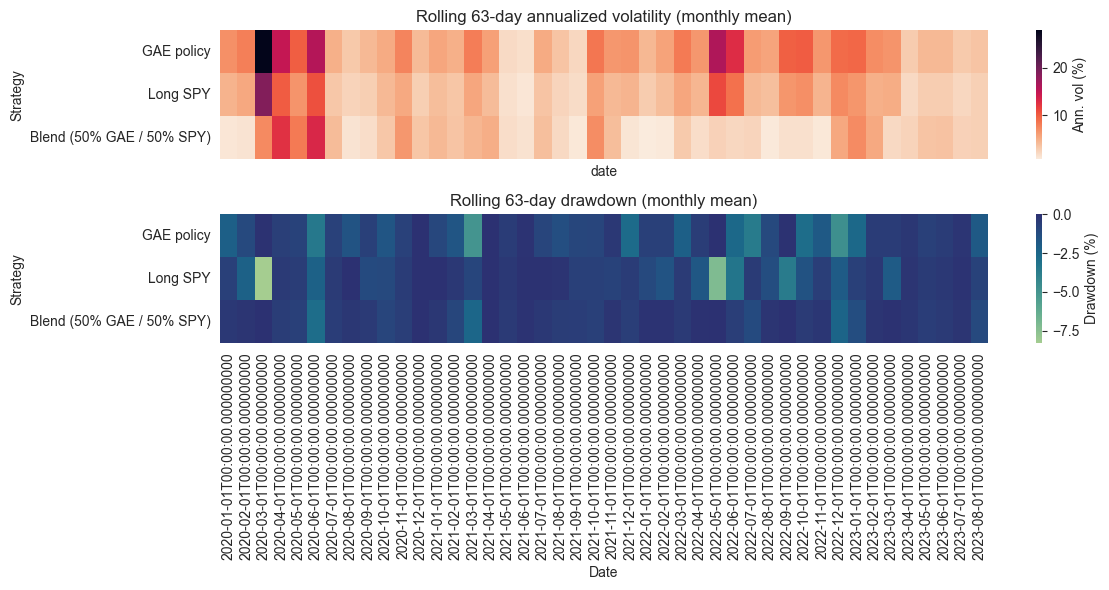

In [17]:
# --- Rolling risk heatmaps ---
def _monthly_average(frame: pd.DataFrame) -> pd.DataFrame:
    if isinstance(frame.index, pd.DatetimeIndex):
        idx = frame.index.to_period('M')
        out = frame.groupby(idx).mean()
        out.index = out.index.to_timestamp()
        return out
    return frame.copy()

heat_vol = _monthly_average(rolling_vol) * 100
heat_dd = _monthly_average(rolling_dd) * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
sns.heatmap(
    heat_vol.T,
    ax=axes[0],
    cmap="rocket_r",
    cbar_kws={"label": "Ann. vol (%)"},
)
axes[0].set_title(f"Rolling {window}-day annualized volatility (monthly mean)")
axes[0].set_ylabel("Strategy")

sns.heatmap(
    heat_dd.T,
    ax=axes[1],
    cmap="crest",
    cbar_kws={"label": "Drawdown (%)"},
)
axes[1].set_title(f"Rolling {window}-day drawdown (monthly mean)")
axes[1].set_ylabel("Strategy")
axes[1].set_xlabel("Date" if isinstance(heat_vol.index, pd.DatetimeIndex) else "Step window")

plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "rolling_risk_heatmaps.png", dpi=150)
plt.show()


#### Weight sweep curve
Varying the GAE allocation illustrates the achievable return/volatility trade-off.


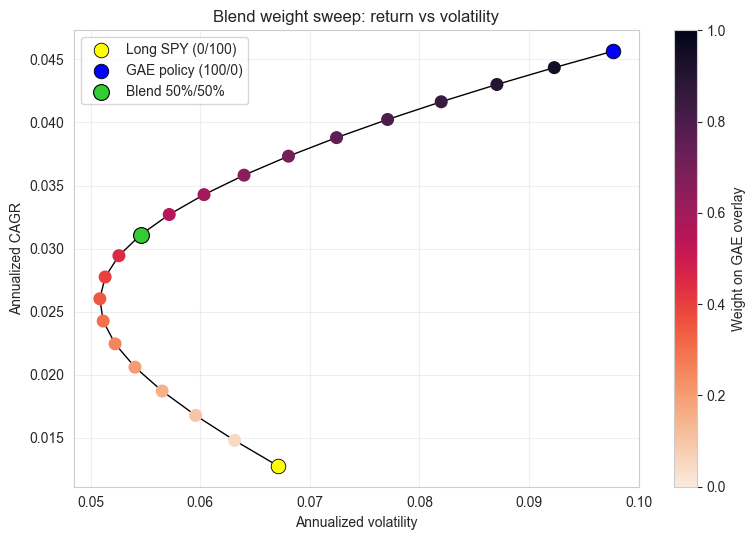

In [18]:
# --- Blend weight sweep: return vs volatility ---
weights = np.linspace(0.0, 1.0, 21)
sweep_records = []
for w in weights:
    combo_r = w * gae_rewards_bps + (1.0 - w) * spy_rewards_bps
    nav_curve = nav_from_bps(combo_r)
    steps = len(combo_r)
    ann_return = nav_curve[-1] ** (252 / steps) - 1.0 if steps else np.nan
    ann_vol = (combo_r / 1e4).std(ddof=1) * np.sqrt(252)
    sweep_records.append({"weight": w, "ann_return": ann_return, "ann_vol": ann_vol})

sweep_df = pd.DataFrame(sweep_records)

fig, ax = plt.subplots(figsize=(8, 5.5))
sc = ax.scatter(
    sweep_df["ann_vol"],
    sweep_df["ann_return"],
    c=sweep_df["weight"],
    cmap="rocket_r",
    s=70,
    zorder=3,
)
ax.plot(sweep_df["ann_vol"], sweep_df["ann_return"], color="0.", lw=1.0, zorder=2)
for w_target, label, color in [
    (0.0, "Long SPY (0/100)", "yellow"),
    (1.0, "GAE policy (100/0)", "blue"),
]:
    row = sweep_df.loc[sweep_df["weight"] == w_target].iloc[0]
    ax.scatter(
        row["ann_vol"],
        row["ann_return"],
        color=color,
        s=110,
        edgecolor="k",
        linewidth=0.6,
        label=label,
        zorder=4,
    )

current_row = sweep_df.iloc[(sweep_df["weight"] - blend_weight).abs().idxmin()]
ax.scatter(
    current_row["ann_vol"],
    current_row["ann_return"],
    color="limegreen",
    edgecolor="k",
    s=130,
    linewidth=0.8,
    label=f"Blend {blend_weight:.0%}/{(1 - blend_weight):.0%}",
    zorder=5,
)
ax.set_xlabel("Annualized volatility")
ax.set_ylabel("Annualized CAGR")
ax.set_title("Blend weight sweep: return vs volatility")
ax.grid(alpha=0.3)
cb = plt.colorbar(sc, ax=ax)
cb.set_label("Weight on GAE overlay")
plt.tight_layout()
plt.legend()
plt.savefig(ROOT / "reports" / "figures" / "blend_weight_sweep.png", dpi=150)
plt.show()


#### PnL attribution bars
Break down the blended PnL into SPY vs overlay contributions by calendar year.


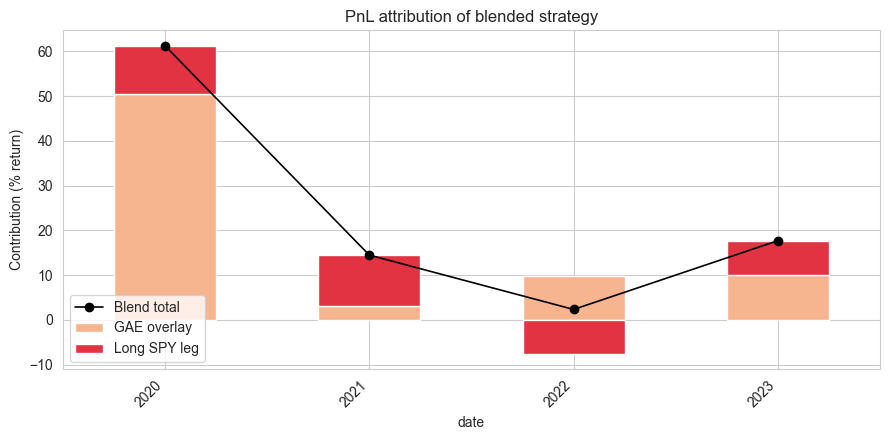

In [19]:
# --- PnL attribution between legs ---
sns.set_palette("rocket_r")

attr_df = pd.DataFrame(
    {
        "GAE overlay": blend_weight * combo_returns["GAE policy"],
        "Long SPY leg": (1.0 - blend_weight) * combo_returns["Long SPY"],
    },
    index=combo_returns.index,
)
attr_df["Blend total"] = attr_df.sum(axis=1)

if isinstance(attr_df.index, pd.DatetimeIndex):
    grouped = attr_df.groupby(attr_df.index.year).sum()
    grouped.index = grouped.index.map(str)
else:
    blocks = 6
    labels = [f"Block {i+1}" for i in range(blocks)]
    cuts = pd.cut(
        np.arange(len(attr_df)),
        bins=np.linspace(0, len(attr_df), blocks + 1),
        labels=labels,
        include_lowest=True,
        right=False,
    )
    grouped = attr_df.groupby(cuts).sum()
    grouped.index = grouped.index.astype(str)

grouped_pct = grouped * 100.0

fig, ax = plt.subplots(figsize=(9, 4.5))
grouped_pct[["GAE overlay", "Long SPY leg"]].plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["C0", "C2"],
)
ax.plot(
    np.arange(len(grouped_pct)),
    grouped_pct["Blend total"],
    color="k",
    marker="o",
    linewidth=1.2,
    label="Blend total",
)
ax.set_ylabel("Contribution (% return)")
ax.set_title("PnL attribution of blended strategy")
ax.set_xticks(range(len(grouped_pct)))
ax.set_xticklabels(grouped_pct.index.tolist(), rotation=45, ha="right")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "blend_pnl_attribution.png", dpi=150)
plt.show()


In [20]:
grouped_pct

,GAE overlay,Long SPY leg,Blend total
date,,,
2020,50.338604,10.874050,61.212654
2021,3.026244,11.442747,14.468990
2022,9.843940,-7.510075,2.333865
2023,10.094039,7.591999,17.686039


In [21]:
# Load diagnostic tables exported by 04_diagnostics
STATS_CSV = ROOT / "reports" /"files" / "stats_summary.csv"
REGIME_CSV = ROOT / "reports" /"files" / "regime_summary.csv"
PERIOD_CSV = ROOT / "reports" /"files" / "period_summary.csv"
ROBUST_CSV = ROOT / "reports" /"files" / "robustness_summary.csv"

stats_df = pd.read_csv(STATS_CSV) if STATS_CSV.exists() else pd.DataFrame()
regime_df = pd.read_csv(REGIME_CSV) if REGIME_CSV.exists() else pd.DataFrame()
period_df = pd.read_csv(PERIOD_CSV) if PERIOD_CSV.exists() else pd.DataFrame()
robust_df = pd.read_csv(ROBUST_CSV) if ROBUST_CSV.exists() else pd.DataFrame()

print({"stats": len(stats_df), "regime": len(regime_df), "period": len(period_df), "robust": len(robust_df)})


{'stats': 18, 'regime': 54, 'period': 34, 'robust': 42}


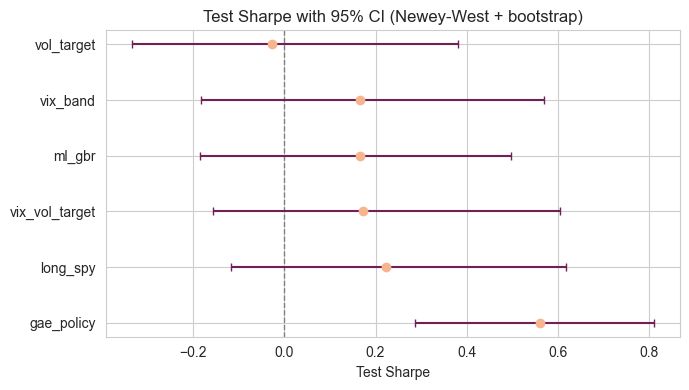

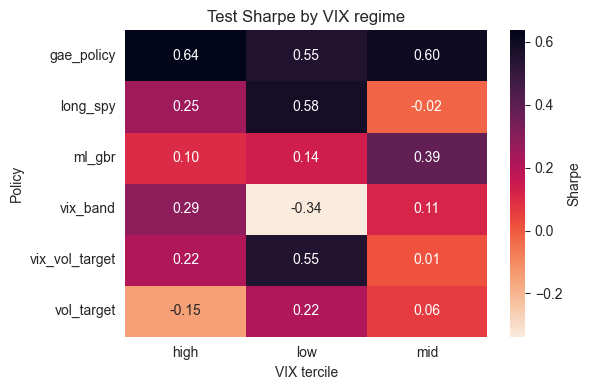

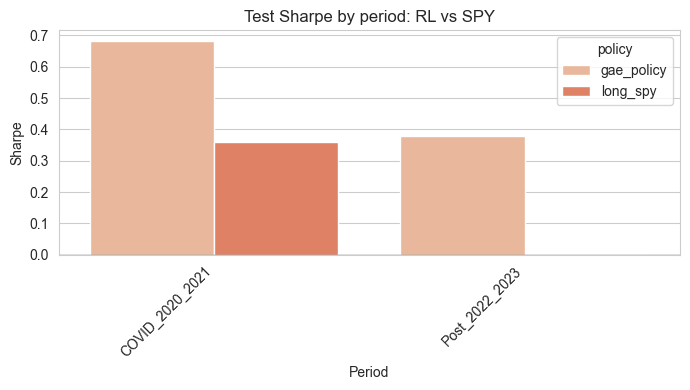

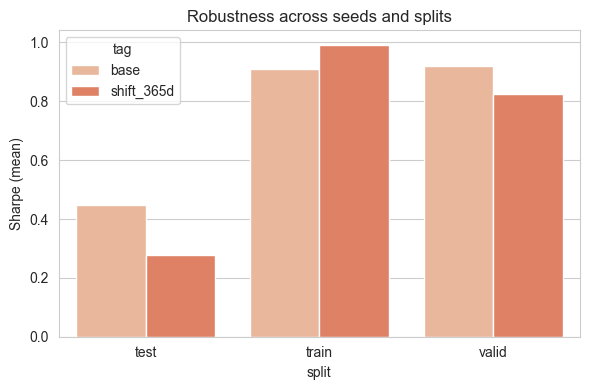

In [22]:
# --- Diagnostics-driven plots (Sharpe CIs, regimes, robustness)
sns.set_style("whitegrid")
sns.set_palette("rocket_r")

# 1) Test Sharpe with Newey-West CI
if not stats_df.empty:
    test_stats = stats_df[stats_df["split"] == "test"].copy()
    test_stats = test_stats.sort_values("sharpe", ascending=False)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.axvline(0.0, color="0.5", lw=1.0, ls="--")
    y = np.arange(len(test_stats))
    ax.errorbar(
        x=test_stats["sharpe"],
        y=y,
        xerr=[test_stats["sharpe"] - test_stats["ci_lo"], test_stats["ci_hi"] - test_stats["sharpe"]],
        fmt="o",
        ecolor="C4",
        color="C0",
        capsize=3,
    )
    ax.set_yticks(y)
    ax.set_yticklabels(test_stats["policy"])
    ax.set_xlabel("Test Sharpe")
    ax.set_title("Test Sharpe with 95% CI (Newey-West + bootstrap)")
    plt.tight_layout()
    plt.savefig(ROOT / "reports" / "figures" / "test_sharpe_cis.png", dpi=150)
    plt.show()

# 2) VIX regime attribution heatmap (test split)
if not regime_df.empty:
    reg_test = regime_df[regime_df["split"] == "test"].copy()
    if not reg_test.empty:
        pivot = reg_test.pivot(index="policy", columns="regime", values="sharpe")
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap="rocket_r", ax=ax, cbar_kws={"label": "Sharpe"})
        ax.set_title("Test Sharpe by VIX regime")
        ax.set_xlabel("VIX tercile")
        ax.set_ylabel("Policy")
        plt.tight_layout()
        plt.savefig(ROOT / "reports" / "figures" / "vix_regime_heatmap.png", dpi=150)
        plt.show()

# 3) Period Sharpe comparison (GAE vs Long SPY, test split)
if not period_df.empty:
    per_test = period_df[period_df["split"] == "test"].copy()
    per_test = per_test[per_test["policy"].isin(["gae_policy", "long_spy"])]
    if not per_test.empty:
        fig, ax = plt.subplots(figsize=(7, 4))
        sns.barplot(data=per_test, x="period", y="sharpe", hue="policy", ax=ax)
        ax.axhline(0.0, color="0.4", lw=1.0)
        ax.set_ylabel("Sharpe")
        ax.set_xlabel("Period")
        ax.set_title("Test Sharpe by period: RL vs SPY")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(ROOT / "reports" / "figures" / "period_sharpe_rl_vs_spy.png", dpi=150)
        plt.show()

# 4) Robustness summary across seeds and shifted splits
if not robust_df.empty:
    bands = (
        robust_df.groupby(["tag", "split"])
        .agg(sharpe_mean=("sharpe", "mean"), sharpe_std=("sharpe", "std"))
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(data=bands, x="split", y="sharpe_mean", hue="tag", ax=ax, errorbar=("sd"))
    ax.set_ylabel("Sharpe (mean)")
    ax.set_title("Robustness across seeds and splits")
    plt.tight_layout()
    plt.savefig(ROOT / "reports" / "figures" / "robustness_summary.png", dpi=150)
    plt.show()
